# Perceptron Implementation

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import random

### File Reading

In [154]:
# Unpacking helper function
def unpack_data(paired_list):
    labels = [label for label, _ in paired_list]
    data = [features for _, features in paired_list]
    return labels, data

In [2]:
labels = []
numbers = []

with open(os.path.join(os.getcwd(), 'data/MNISTnumLabels5000_balanced.txt'), 'r+') as f:
    lines = f.readlines()
    for line in lines:
        labels.append(int(line))

with open(os.path.join(os.getcwd(), 'data/MNISTnumImages5000_balanced.txt'), 'r+') as f:
    lines = f.readlines()
    for line in lines:
        ind_line = line.split('\t')
        ind_line = [float(i) for i in ind_line]

        numbers.append(ind_line)
    

labels = np.array(labels)
numbers = np.array(numbers)

#### Example of how we will be displaying numbers

0


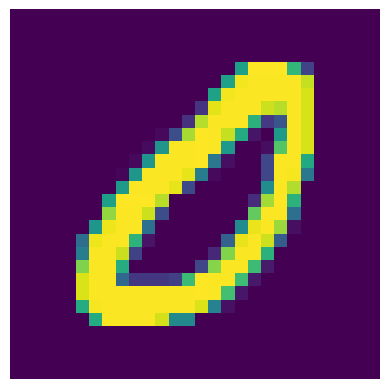

In [8]:
index = random.randint(0, 4999)

example_number = numbers[index]
example_label = labels[index]
matrix = example_number.reshape(28, 28).T

print(example_label)
plt.imshow(matrix)
plt.axis('off')
plt.show()

## Step 1: Data Randomization

In [52]:
zeroes_and_nines_train = []
zeroes_and_nines_test = []
zero_count = 0
nine_count = 0
new_labels = []
test_labels = []
for i in range(len(numbers)):
    if labels[i] == 0 or labels[i] == 9:
        zero_count += 1 if labels[i] == 0 else 0
        nine_count += 1 if labels[i] == 9 else 0

        if labels[i] == 0 and zero_count > 400:
            zeroes_and_nines_test.append(numbers[i])
            test_labels.append(labels[i])
            continue
        
        if labels[i] == 9 and nine_count > 400:
            zeroes_and_nines_test.append(numbers[i])
            test_labels.append(labels[i])
            continue

        zeroes_and_nines_train.append(numbers[i])
        new_labels.append(labels[i])


# Time to shuffle!
combined_train_data = list(zip(new_labels, zeroes_and_nines_train))
random.shuffle(combined_train_data)

combined_test_data = list(zip(test_labels, zeroes_and_nines_test))
random.shuffle(combined_test_data)

In [53]:
# Challenge set
challenge_set = []
challenge_labels = []

# Track how many of each digit (1–8) we’ve taken
digits = {d: 0 for d in range(1, 9)}

for i in range(len(numbers)):
    label = labels[i]  # get the digit for this image
    
    # only use digits 1–8, and only take 100 of each
    if label in digits and digits[label] < 100:
        challenge_set.append(numbers[i])
        challenge_labels.append(label)
        digits[label] += 1

    # if we’ve collected 100 of all 1–8, we can stop
    if all(count == 100 for count in digits.values()):
        break

combined_challenge_data = list(zip(challenge_labels, challenge_set))
random.shuffle(combined_challenge_data)

## Step 2: Perceptron

In [181]:
# I am considering 0 = 0, 1 = 9

w = np.random.uniform(0, 0.5, size=785)  # includes bias weight

def perceptron_run(number_array, w):
    x0 = 1
    input_array = np.insert(number_array, 0, x0)  # prepend bias input
    
    summation = np.dot(w, input_array)  # weighted sum

    # Activation function (step)
    output = 1 if summation > 0 else 0

    return output

In [113]:
index = random.randint(0, 799)
test_s = perceptron_run(combined_train_data[index][1], w)
test_s

(33.905306796937886, 1)

## Step 3: Accuracy Scores

In [137]:
def error_fractions(p_output, truths):
    wrong_answer_count = 0

    for i in range(len(p_output)):
        if p_output[i] != truths[i]:
            wrong_answer_count += 1
    
    return wrong_answer_count/len(truths)

def positives_counter(p_output, truths):
    true_positives = 0
    false_positives = 0
    true_negatives = 0
    false_negatives = 0

    for i in range(len(p_output)):
        if p_output[i] == 1 and truths[i] == 1:
            true_positives += 1
        
        elif p_output[i] == 0 and truths[i] == 0:
            true_negatives += 1

        elif p_output[i] == 1 and truths[i] == 0:
            false_positives += 1
        
        elif p_output[i] == 0 and truths[i] == 1:
            false_negatives += 1

    return (true_positives, true_negatives, false_positives, false_negatives)

def precision_score(p_output, truths):
    true_positives, _, false_positives, _ = positives_counter(p_output, truths)

    return (true_positives / (true_positives + false_positives))

def recall_score(p_output, truths):
    true_positives, _, _, false_negatives = positives_counter(p_output, truths)

    return (true_positives / (true_positives + false_negatives))

def f1_score(p_output, truths):
    prec_score = precision_score(p_output, truths)
    rec_score = recall_score(p_output, truths)

    return (2 * ((prec_score * rec_score) / (prec_score + rec_score)))

In [182]:
# Initial accuracy tests
perceptron_outputs = []
true_outputs = []

# With the train set
for label, number in combined_train_data:
    perceptron_outputs.append(perceptron_run(number_array=number, w=w))
    true_outputs.append(1 if label == 9 else 0)

print(f"Error Fraction: {error_fractions(perceptron_outputs, true_outputs)}")

true_positives, true_negatives, false_positives, false_negatives = positives_counter(perceptron_outputs, true_outputs)
print(f"True positives: {true_positives}, True negatives: {true_negatives}, False positives: {false_positives}, False negatives: {false_negatives}")

print(f"Precision score: {precision_score(perceptron_outputs, true_outputs)}")

print(f"Recall score: {recall_score(perceptron_outputs, true_outputs)}")

print(f"F1 score: {f1_score(perceptron_outputs, true_outputs)}")

Error Fraction: 0.5
True positives: 400, True negatives: 0, False positives: 400, False negatives: 0
Precision score: 0.5
Recall score: 1.0
F1 score: 0.6666666666666666


## Step 4: Training the Perceptron

In [143]:
np.array(true_outputs) - np.array(perceptron_outputs)

array([-1,  0,  0, -1, -1,  0, -1,  0,  0,  0,  0,  0,  0, -1, -1,  0,  0,
        0,  0,  0,  0, -1,  0, -1,  0,  0, -1, -1,  0, -1, -1, -1,  0, -1,
        0, -1, -1, -1,  0, -1, -1,  0,  0,  0, -1,  0,  0, -1, -1,  0,  0,
        0,  0,  0,  0, -1, -1,  0,  0,  0,  0,  0, -1,  0,  0, -1, -1,  0,
       -1,  0,  0, -1,  0,  0,  0, -1,  0, -1,  0,  0,  0, -1, -1, -1, -1,
       -1, -1,  0, -1, -1,  0,  0,  0, -1, -1, -1,  0, -1,  0,  0,  0, -1,
        0,  0,  0, -1, -1,  0, -1, -1, -1, -1,  0, -1, -1, -1,  0,  0, -1,
        0, -1, -1, -1, -1, -1, -1, -1,  0,  0,  0,  0,  0,  0, -1,  0, -1,
       -1,  0, -1,  0, -1, -1, -1, -1, -1,  0,  0,  0, -1,  0,  0, -1,  0,
        0,  0,  0, -1,  0, -1, -1,  0, -1,  0, -1,  0, -1,  0, -1, -1, -1,
        0,  0, -1, -1,  0, -1,  0,  0, -1, -1,  0,  0, -1, -1,  0, -1, -1,
       -1,  0,  0, -1,  0, -1,  0,  0,  0,  0,  0, -1,  0, -1, -1,  0, -1,
        0, -1, -1, -1,  0, -1,  0,  0, -1,  0, -1, -1,  0,  0,  0,  0, -1,
        0,  0, -1,  0, -1

In [185]:
lr = 0.01
num_epochs = 1000
w = np.random.uniform(0, 0.5, size=785)  
labels, perc_inputs = unpack_data(combined_train_data)
labels = [0 if lbl == 0 else 1 for lbl in labels]
perc_inputs = perc_inputs

for i in range(num_epochs):
    print(f"Epoch number {i}")
    for index in range(len(perc_inputs)):
        perceptron_outputs = perceptron_run(perc_inputs[index], w)

        error = labels[index] - perceptron_outputs

        w = w + (lr * (error) * (np.insert(perc_inputs[index], 0, 1))) 
        w[0] = w[0] + (lr * error)

Epoch number 0
Epoch number 1
Epoch number 2
Epoch number 3
Epoch number 4
Epoch number 5
Epoch number 6
Epoch number 7
Epoch number 8
Epoch number 9
Epoch number 10
Epoch number 11
Epoch number 12
Epoch number 13
Epoch number 14
Epoch number 15
Epoch number 16
Epoch number 17
Epoch number 18
Epoch number 19
Epoch number 20
Epoch number 21
Epoch number 22
Epoch number 23
Epoch number 24
Epoch number 25
Epoch number 26
Epoch number 27
Epoch number 28
Epoch number 29
Epoch number 30
Epoch number 31
Epoch number 32
Epoch number 33
Epoch number 34
Epoch number 35
Epoch number 36
Epoch number 37
Epoch number 38
Epoch number 39
Epoch number 40
Epoch number 41
Epoch number 42
Epoch number 43
Epoch number 44
Epoch number 45
Epoch number 46
Epoch number 47
Epoch number 48
Epoch number 49
Epoch number 50
Epoch number 51
Epoch number 52
Epoch number 53
Epoch number 54
Epoch number 55
Epoch number 56
Epoch number 57
Epoch number 58
Epoch number 59
Epoch number 60
Epoch number 61
Epoch number 62
Ep

In [186]:
# Testing with train set after training
perceptron_outputs = []
true_outputs = []

# With the train set
for label, number in combined_train_data:
    perceptron_outputs.append(perceptron_run(number_array=number, w=w))
    true_outputs.append(1 if label == 9 else 0)

print(f"Error Fraction: {error_fractions(perceptron_outputs, true_outputs)}")

true_positives, true_negatives, false_positives, false_negatives = positives_counter(perceptron_outputs, true_outputs)
print(f"True positives: {true_positives}, True negatives: {true_negatives}, False positives: {false_positives}, False negatives: {false_negatives}")

print(f"Precision score: {precision_score(perceptron_outputs, true_outputs)}")

print(f"Recall score: {recall_score(perceptron_outputs, true_outputs)}")

print(f"F1 score: {f1_score(perceptron_outputs, true_outputs)}")

Error Fraction: 0.0
True positives: 400, True negatives: 400, False positives: 0, False negatives: 0
Precision score: 1.0
Recall score: 1.0
F1 score: 1.0


Perceptron Prediction: 9


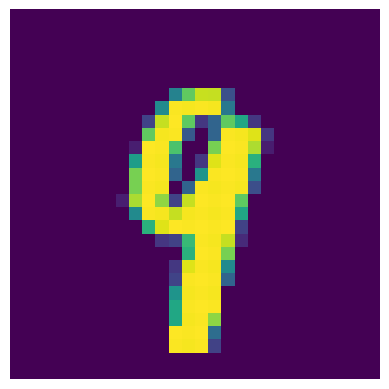

In [193]:
index = random.randint(0, 799)
matrix = perc_inputs[index]
label = labels[index]

perc_output = 9 if perceptron_run(matrix, w) == 1 else 0
print(f"Perceptron Prediction: {perc_output}")
plt.imshow(matrix.reshape(28,28).T)
plt.axis('off')
plt.show()